In [156]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from tqdm.notebook import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import re
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from matplotlib import pyplot
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score, precision_recall_curve, auc, roc_auc_score, roc_curve, make_scorer
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier as XGBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

In [202]:
# Function created to retrieve data from URLs
def retrieve_bs(page):
    r = requests.get(page)
    soup = BeautifulSoup(r.text, 'html.parser')
    return soup

# Function created to retrieve each review from the dataset
def retrieve_reviews(soup):
    reviews_data = []
    
    text_title_div = soup.find('div', {'class' : 'BookPageTitleSection__title'})
    if text_title_div:
        text_title = text_title_div.find('h1', {'aria-label': True}) #Data required subsetting to retrieve text
        if text_title:
            book_title = text_title['aria-label'].replace('Book title: ','').strip() # remove white space
        else:
            book_title = 'Unknown Title'
    else:
        book_title = 'Unknown title'
    
    
    reviews = soup.findAll('section', {'class' : 'ReviewCard__content'})
    for item in reviews:
        
        review = {
            'book_title' : book_title,
            'date' : None,
            'rating' : None,
            'review_text' : None
        }
        
        # Extract the review date
        date_span = item.find('span', {'class' : 'Text Text__body3'})
        if date_span:
            review['date'] = date_span.text.strip()
        
        # Extract the rating
        shelf_status_div = item.find('div', {'class': 'ShelfStatus'})
        if shelf_status_div:
            rating_span = shelf_status_div.find('span', {'aria-label': True})
            if rating_span:
                # Keep only the review number from the text.
                review['rating'] = float(rating_span['aria-label'].replace('Rating ', '').replace('out of 5','').strip()) 
                
            
        # Extract the review text    
        review_span = item.find('span', class_= 'Formatted')    
        if review_span:
            review['review_text'] = review_span.text.strip()
            
        reviews_data.append(review)
        
    return reviews_data



In [14]:
urls = [
    # All of the URLs to be extracted. Each URL is a different book.
    'https://www.goodreads.com/book/show/16113737-the-reason-i-jump?from_search=true&from_srp=true&qid=DQxqMgCLv6&rank=1',
    'https://www.goodreads.com/book/show/58537365-unmasking-autism?from_search=true&from_srp=true&qid=DQxqMgCLv6&rank=2',
    'https://www.goodreads.com/book/show/22514020-neurotribes?from_search=true&from_srp=true&qid=DQxqMgCLv6&rank=3',
    'https://www.goodreads.com/book/show/103408.Thinking_in_Pictures?from_search=true&from_srp=true&qid=DQxqMgCLv6&rank=4',
    'https://www.goodreads.com/book/show/7366.Animals_in_Translation?from_search=true&from_srp=true&qid=DQxqMgCLv6&rank=5',
    'https://www.goodreads.com/book/show/25430558-in-a-different-key?from_search=true&from_srp=true&qid=DQxqMgCLv6&rank=6',
    'https://www.goodreads.com/book/show/23492643-uniquely-human?from_search=true&from_srp=true&qid=DQxqMgCLv6&rank=7',
    'https://www.goodreads.com/book/show/55985404-we-re-not-broken?from_search=true&from_srp=true&qid=DQxqMgCLv6&rank=8',
    'https://www.goodreads.com/book/show/40552513-the-warner-boys?from_search=true&from_srp=true&qid=DQxqMgCLv6&rank=9',
    'https://www.goodreads.com/book/show/978904.Gut_and_Psychology_Syndrome?from_search=true&from_srp=true&qid=DQxqMgCLv6&rank=10',
    'https://www.goodreads.com/book/show/35756912-autism-in-heels?from_search=true&from_srp=true&qid=DQxqMgCLv6&rank=11',
    'https://www.goodreads.com/book/show/3394503-the-way-i-see-it?from_search=true&from_srp=true&qid=DQxqMgCLv6&rank=12',
    'https://www.goodreads.com/book/show/12671833-carly-s-voice?from_search=true&from_srp=true&qid=DQxqMgCLv6&rank=14',
    'https://www.goodreads.com/book/show/12284375-temple-grandin?from_search=true&from_srp=true&qid=DQxqMgCLv6&rank=15',
    'https://www.goodreads.com/book/show/62842156-what-i-mean-when-i-say-i-m-autistic?from_search=true&from_srp=true&qid=DQxqMgCLv6&rank=16',
    'https://www.goodreads.com/book/show/26109012-accessing-the-healing-power-of-the-vagus-nerve?from_search=true&from_srp=true&qid=DQxqMgCLv6&rank=17',
    'https://www.goodreads.com/book/show/32830247-fall-down-7-times-get-up-8?from_search=true&from_srp=true&qid=DQxqMgCLv6&rank=18',
    'https://www.goodreads.com/book/show/163659.Ten_Things_Every_Child_with_Autism_Wishes_You_Knew?from_search=true&from_srp=true&qid=DQxqMgCLv6&rank=19',
    'https://www.goodreads.com/book/show/36236157-asperger-s-children?from_search=true&from_srp=true&qid=DQxqMgCLv6&rank=20'
    'https://www.goodreads.com/book/show/197392675-but-everyone-feels-this-way?from_search=true&from_srp=true&qid=DQxqMgCLv6&rank=21'
    ]

all_reviews = []

for url in urls:
    #for loop which applies call the function created
    soup = retrieve_bs(url)
    reviews_data = retrieve_reviews(soup)
    all_reviews.extend(reviews_data)

In [15]:
df = pd.DataFrame(all_reviews)
# using pandas to create a dataframe and cleaning any blank values
df2 = df.dropna()
# Include an index column for merging later
df2['id'] = df2.index + 1
df2

C:\Users\User\AppData\Local\Temp\ipykernel_13156\3440808393.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['id'] = df2.index + 1


,book_title,date,rating,review_text,id
0,The Reason I Jump: the Inner Voice of a Thirte...,"July 15, 2013",5.0,"(Note: I have autism)I have to admit, I was on...",1
1,The Reason I Jump: the Inner Voice of a Thirte...,"August 11, 2024",5.0,This is a great book to be written by someone ...,2
2,The Reason I Jump: the Inner Voice of a Thirte...,"October 23, 2013",5.0,This is the most illuminating insight into the...,3
3,The Reason I Jump: the Inner Voice of a Thirte...,"January 23, 2023",4.0,Update Why have I gone back to his review afte...,4
4,The Reason I Jump: the Inner Voice of a Thirte...,"January 13, 2016",1.0,I would be skeptical that this book was writte...,5
...,...,...,...,...,...
565,Asperger's Children: The Origins of Autism in ...,"July 24, 2023",4.0,Niesamowicie wyważona i mocno oparta na dokume...,566
566,Asperger's Children: The Origins of Autism in ...,"October 12, 2018",5.0,"This is, quite possibly, the hardest book I ha...",567
567,Asperger's Children: The Origins of Autism in ...,"February 13, 2020",2.0,Autorka przedstawia szczególny wycinek XX-wiec...,568
568,Asperger's Children: The Origins of Autism in ...,"October 20, 2018",5.0,This is the toughest book review I’ve ever wri...,569


In [16]:
duplicates = df2[df2.duplicated()]
#Check to see if there are any duplicates in the data.
duplicates

,book_title,date,rating,review_text,id


Text(0.5, 0, 'Review score')

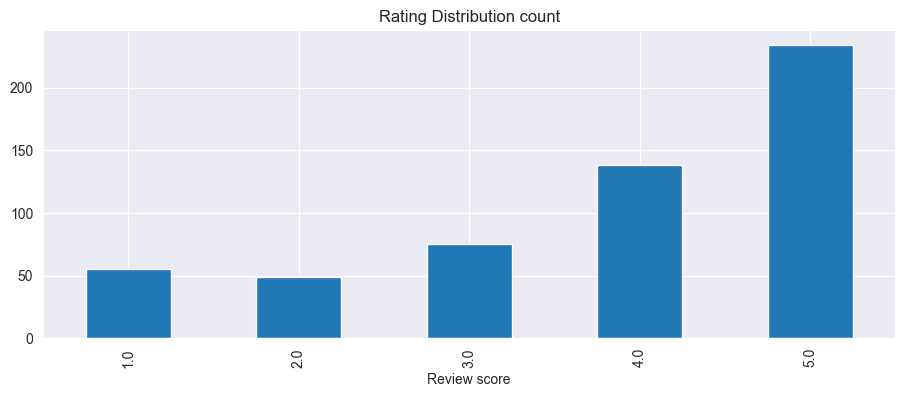

In [106]:
plt.figure(figsize= (11,4))
# Visualisation for the rating scores for all the reviews
rating_score_data = df2['rating'].value_counts().sort_index().plot(kind='bar', title='Rating Distribution count')
rating_score_data.set_xlabel('Review score')


In [203]:
example = df2['review_text'][0]
# Viewing a review in the dataset
example

"(Note: I have autism)I have to admit, I was on the verge of crying at some partsbecause this book is everything I've wanted to tell the world but didn't know howit made me understand myself a bit better, because like the author, I am not always sure why I do the things I doIt is one of those books I want as many as people as possible to read, to try and understand people with autism a bit better, and get rid of misconceptions."

In [205]:
tokens = nltk.word_tokenize(example)
# Applying tokenisation from the review.
tokens[:10]

['(', 'Note', ':', 'I', 'have', 'autism', ')', 'I', 'have', 'to']

In [20]:
pos = nltk.pos_tag(tokens)
# Adding parts of speech to the tokens

In [161]:
groups = nltk.chunk.ne_chunk(pos)
# Chuncking the parts of speech together
groups.pprint()

(S
  I/PRP
  found/VBD
  this/DT
  near/JJ
  unreadable/JJ
  ./.
  I/PRP
  hoped/VBD
  this/DT
  would/MD
  be/VB
  about/IN
  masking/VBG
  and/CC
  unmasking/JJ
  autism/NN
  ,/,
  instead/RB
  it/PRP
  's/VBZ
  anecdotal/JJ
  ,/,
  personal/JJ
  and/CC
  has/VBZ
  a/DT
  structure/NN
  that/WDT
  made/VBD
  me/PRP
  want/VB
  to/TO
  tear/VB
  my/PRP$
  hair/NN
  out/RP
  ./.
  Unlike/IN
  the/DT
  author/NN
  I/PRP
  do/VBP
  think/VB
  strict/VB
  guidelines/NNS
  what/WP
  is/VBZ
  and/CC
  is/VBZ
  n't/RB
  autism/NN
  can/MD
  be/VB
  helpful/JJ
  (/(
  because/IN
  what/WP
  even/RB
  are/VBP
  we/PRP
  talking/VBG
  about/IN
  if/IN
  the/DT
  diagnosis/NN
  is/VBZ
  as/RB
  vague/JJ
  as/IN
  (ORGANIZATION Price/NN)
  wants/VBZ
  it/PRP
  to/TO
  be/VB
  ?/.
  )/)
  and/CC
  I/PRP
  think/VBP
  diagnosis/NN
  is/VBZ
  relevent/JJ
  ./.
  If/IN
  it/PRP
  were/VBD
  possible/JJ
  ,/,
  I/PRP
  'd/MD
  get/VB
  tested/VBN
  myself/PRP
  ,/,
  but/CC
  as/IN
  of/IN
  now/RB
  

In [21]:
sent = SentimentIntensityAnalyzer()
# Utilizing the sentiment analyser

In [22]:
polarity_scores = {}
# Creating the polarity scores for all the text in the dataset.

for i, row in tqdm(df2.iterrows(), total=len(df2)):
    text = row['review_text']
    ID = row['id']
    polarity_scores[ID] = sent.polarity_scores(text)
    

  0%|          | 0/551 [00:00<?, ?it/s]

In [23]:
polarity_scores 
# Transpose the dataframe
vader_score = pd.DataFrame(polarity_scores).T
# rename the index column to id
vader_score = vader_score.reset_index().rename(columns={'index': 'id'})
# Merge the two datasets together
merged_df = vader_score.merge(df2, how='left')

In [207]:
vader_score

,id,neg,neu,pos,compound
0,1,0.051,0.790,0.158,0.8522
1,2,0.046,0.817,0.137,0.9899
2,3,0.078,0.857,0.065,-0.3699
3,4,0.089,0.792,0.119,0.9757
4,5,0.089,0.776,0.135,0.8793
...,...,...,...,...,...
546,566,0.000,1.000,0.000,0.0000
547,567,0.090,0.810,0.101,0.6345
548,568,0.000,1.000,0.000,0.0000
549,569,0.114,0.799,0.086,-0.8070


In [24]:
merged_df

,id,neg,neu,pos,compound,book_title,date,rating,review_text
0,1,0.051,0.790,0.158,0.8522,The Reason I Jump: the Inner Voice of a Thirte...,"July 15, 2013",5.0,"(Note: I have autism)I have to admit, I was on..."
1,2,0.046,0.817,0.137,0.9899,The Reason I Jump: the Inner Voice of a Thirte...,"August 11, 2024",5.0,This is a great book to be written by someone ...
2,3,0.078,0.857,0.065,-0.3699,The Reason I Jump: the Inner Voice of a Thirte...,"October 23, 2013",5.0,This is the most illuminating insight into the...
3,4,0.089,0.792,0.119,0.9757,The Reason I Jump: the Inner Voice of a Thirte...,"January 23, 2023",4.0,Update Why have I gone back to his review afte...
4,5,0.089,0.776,0.135,0.8793,The Reason I Jump: the Inner Voice of a Thirte...,"January 13, 2016",1.0,I would be skeptical that this book was writte...
...,...,...,...,...,...,...,...,...,...
546,566,0.000,1.000,0.000,0.0000,Asperger's Children: The Origins of Autism in ...,"July 24, 2023",4.0,Niesamowicie wyważona i mocno oparta na dokume...
547,567,0.090,0.810,0.101,0.6345,Asperger's Children: The Origins of Autism in ...,"October 12, 2018",5.0,"This is, quite possibly, the hardest book I ha..."
548,568,0.000,1.000,0.000,0.0000,Asperger's Children: The Origins of Autism in ...,"February 13, 2020",2.0,Autorka przedstawia szczególny wycinek XX-wiec...
549,569,0.114,0.799,0.086,-0.8070,Asperger's Children: The Origins of Autism in ...,"October 20, 2018",5.0,This is the toughest book review I’ve ever wri...


In [25]:
# remove reviews that are neutral as 1.0 score as these reviews are in another language
merged_df2 = merged_df[merged_df['neu'] != 1.0].reset_index(drop=True)
print(merged_df2)

      id    neg    neu    pos  compound  \
0      1  0.051  0.790  0.158    0.8522   
1      2  0.046  0.817  0.137    0.9899   
2      3  0.078  0.857  0.065   -0.3699   
3      4  0.089  0.792  0.119    0.9757   
4      5  0.089  0.776  0.135    0.8793   
..   ...    ...    ...    ...       ...   
525  564  0.242  0.665  0.093   -0.9943   
526  565  0.132  0.823  0.046   -0.8049   
527  567  0.090  0.810  0.101    0.6345   
528  569  0.114  0.799  0.086   -0.8070   
529  570  0.151  0.849  0.000   -0.8801   

                                            book_title               date  \
0    The Reason I Jump: the Inner Voice of a Thirte...      July 15, 2013   
1    The Reason I Jump: the Inner Voice of a Thirte...    August 11, 2024   
2    The Reason I Jump: the Inner Voice of a Thirte...   October 23, 2013   
3    The Reason I Jump: the Inner Voice of a Thirte...   January 23, 2023   
4    The Reason I Jump: the Inner Voice of a Thirte...   January 13, 2016   
..                   

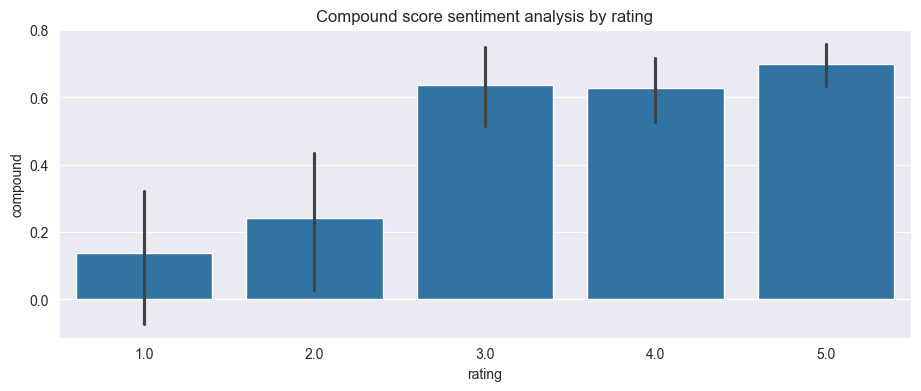

In [26]:
# Compound score visual exploratory data analysis
plt.figure(figsize= (11,4))
compound_bar = sns.barplot(data=merged_df, x='rating', y='compound')
compound_bar.set_title('Compound score sentiment analysis by rating')
plt.show()


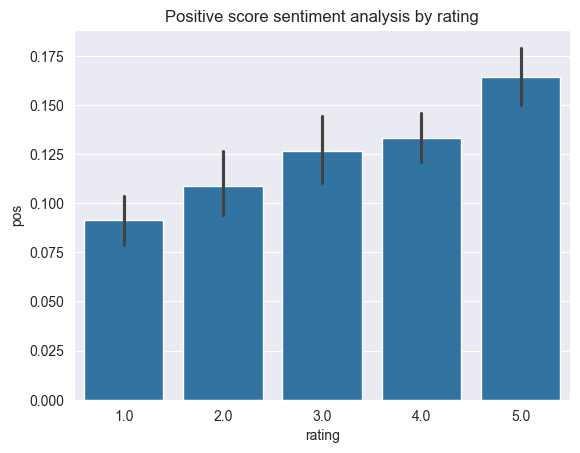

In [206]:
# Positive score visual exploratory data analysis
positive_bar = sns.barplot(data=merged_df, x='rating', y='pos')
positive_bar.set_title('Positive score sentiment analysis by rating')
plt.show()

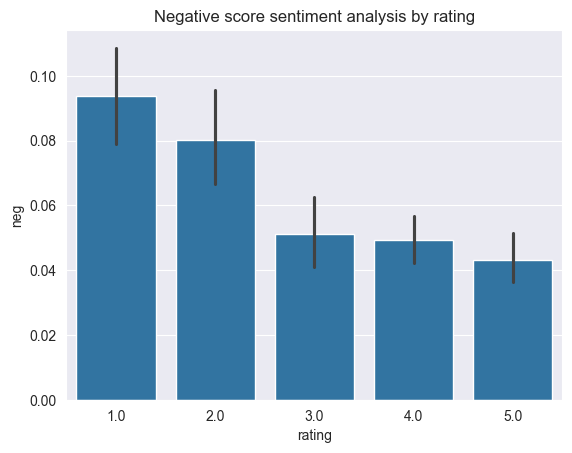

In [28]:
# Negative score visual exploratory data analysis
plt.show()
negative_bar = sns.barplot(data=merged_df, x='rating', y='neg')
negative_bar.set_title('Negative score sentiment analysis by rating')
plt.show()

In [29]:
def text_preprocessing(uncleaned_text_corpus): # cleans the corpus removing stop words and none alphabetical letters
    corpus = []
    for i in range(0, len(uncleaned_text_corpus)):
      description = re.sub('[^a-zA-Z]', ' ',uncleaned_text_corpus[i])
      description = description.lower()
      description = description.split()
      lemmatizer = WordNetLemmatizer() # lemmatizer used
      all_stopwords = stopwords.words('english')
      all_stopwords.remove('not')
      description = [lemmatizer.lemmatize(word) for word in description if not word in set(all_stopwords)]
      description = ' '.join(description)
      corpus.append(description)
    return corpus

# Creates a new column that contains the cleaned review in the dataset
merged_df2['Cleaned_review'] = text_preprocessing(merged_df2['review_text'])

In [30]:
# Create positive and negative classification column by converting the compound score
merged_df2['sentiment_label'] = np.where(merged_df2['compound'] > 0.5, 'positive', 'negative')

Text(0, 0.5, 'Count')

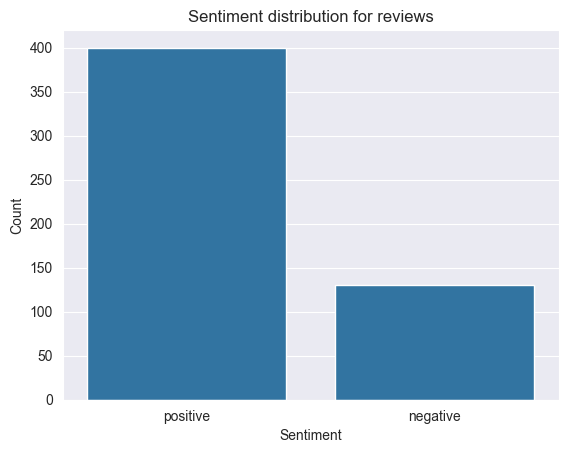

In [208]:
# Sentiment distibution visual exploratory data analysis
sentiment_counts = merged_df2['sentiment_label'].value_counts().reset_index()
sentiment_counts.columns = ['sentiment_label', 'sentiment_count']
sns.barplot(x='sentiment_label', y='sentiment_count', data=sentiment_counts)
plt.title('Sentiment distribution for reviews')
plt.xlabel('Sentiment')
plt.ylabel('Count')


In [33]:
# Create a word count column
merged_df2['word_count'] = merged_df2['review_text'].apply(lambda x: len(x.split()))


In [34]:
merged_df2

,id,neg,neu,pos,compound,book_title,date,rating,review_text,Cleaned_review,sentiment_label,word_count
0,1,0.051,0.790,0.158,0.8522,The Reason I Jump: the Inner Voice of a Thirte...,"July 15, 2013",5.0,"(Note: I have autism)I have to admit, I was on...",note autism admit verge cry partsbecause book ...,positive,84
1,2,0.046,0.817,0.137,0.9899,The Reason I Jump: the Inner Voice of a Thirte...,"August 11, 2024",5.0,This is a great book to be written by someone ...,great book written someone age fact written ye...,positive,372
2,3,0.078,0.857,0.065,-0.3699,The Reason I Jump: the Inner Voice of a Thirte...,"October 23, 2013",5.0,This is the most illuminating insight into the...,illuminating insight mind autistic child seen ...,negative,741
3,4,0.089,0.792,0.119,0.9757,The Reason I Jump: the Inner Voice of a Thirte...,"January 23, 2023",4.0,Update Why have I gone back to his review afte...,update gone back review year review much gr fr...,positive,681
4,5,0.089,0.776,0.135,0.8793,The Reason I Jump: the Inner Voice of a Thirte...,"January 13, 2016",1.0,I would be skeptical that this book was writte...,would skeptical book written year old without ...,positive,307
...,...,...,...,...,...,...,...,...,...,...,...,...
525,564,0.242,0.665,0.093,-0.9943,Asperger's Children: The Origins of Autism in ...,"October 30, 2019",3.0,This is one of the most chilling books I’ve re...,one chilling book read individual story suffer...,negative,245
526,565,0.132,0.823,0.046,-0.8049,Asperger's Children: The Origins of Autism in ...,"December 10, 2018",4.0,This book has a lot of shocking and important ...,book lot shocking important information said f...,negative,71
527,567,0.090,0.810,0.101,0.6345,Asperger's Children: The Origins of Autism in ...,"October 12, 2018",5.0,"This is, quite possibly, the hardest book I ha...",quite possibly hardest book ever read not poor...,positive,928
528,569,0.114,0.799,0.086,-0.8070,Asperger's Children: The Origins of Autism in ...,"October 20, 2018",5.0,This is the toughest book review I’ve ever wri...,toughest book review ever written not since th...,negative,247


In [35]:
# View summary statistics of the data
merged_df2.describe()

,id,neg,neu,pos,compound,rating,word_count
count,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000
mean,281.658491,0.056215,0.799134,0.144645,0.599270,3.807547,247.860377
std,162.333429,0.056690,0.091261,0.091221,0.597015,1.337527,260.596124
min,1.000000,0.000000,0.175000,0.000000,-0.996800,1.000000,2.000000
25%,141.250000,0.020250,0.763000,0.092000,0.512050,3.000000,80.250000
50%,283.500000,0.047000,0.808500,0.129000,0.904200,4.000000,170.000000
75%,416.750000,0.080000,0.856750,0.178000,0.976000,5.000000,321.250000
max,570.000000,0.773000,0.979000,0.825000,0.999700,5.000000,2065.000000


Text(0.5, 1.0, 'Number of reviews for each book')

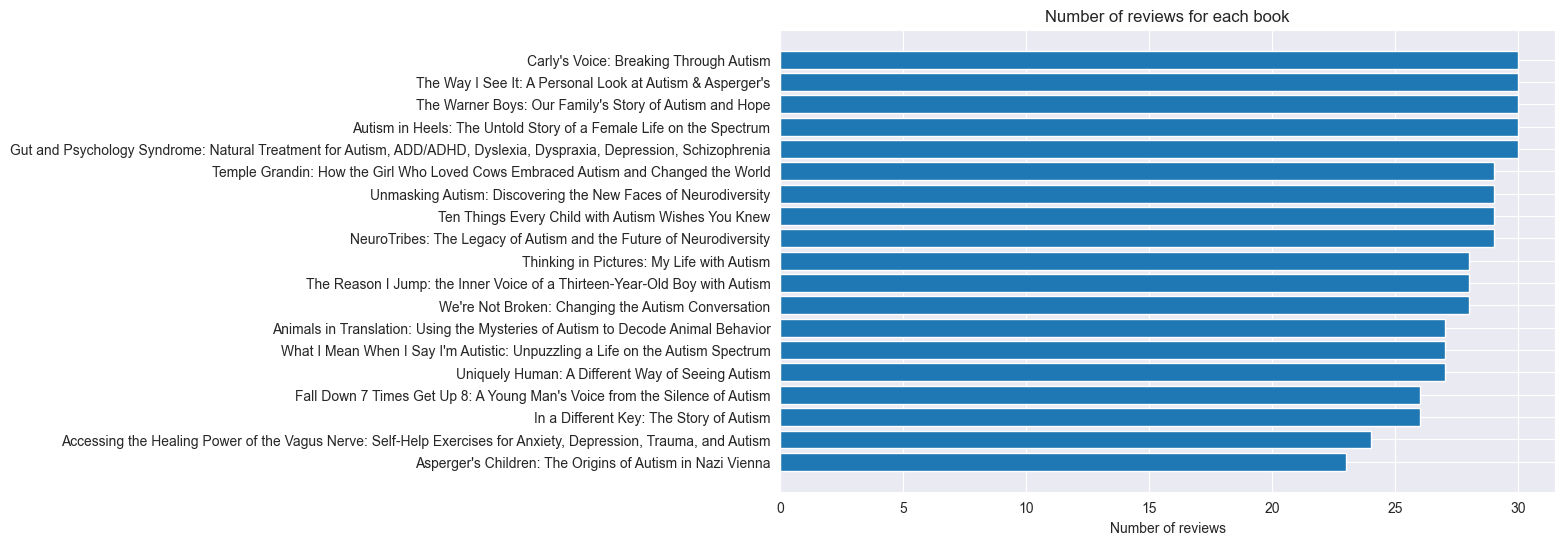

In [98]:
# Exploratory data analysis of the review counts for each book
review_counts = merged_df2.groupby('book_title').size().reset_index(name='review_count').sort_values(by='review_count')
plt.figure(figsize=(10, 6))
plt.barh(review_counts['book_title'], review_counts['review_count'])
plt.xlabel('Number of reviews')
plt.title('Number of reviews for each book')

Text(0.5, 1.0, 'The average rating score for each book')

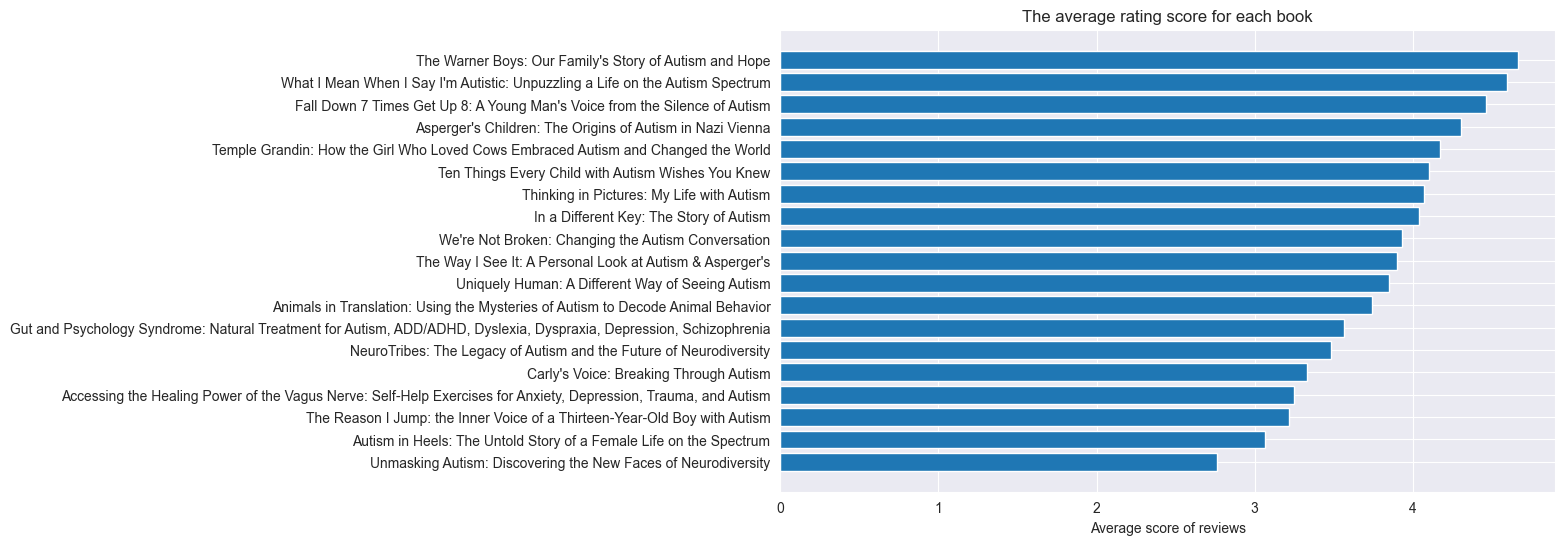

In [102]:
# Exploratory data analysis of the average rating score for each book
average_ratings = merged_df2.groupby('book_title')['rating'].mean().reset_index(name='average_ratings').sort_values(by='average_ratings')
plt.figure(figsize=(10,6))
plt.barh(average_ratings['book_title'], average_ratings['average_ratings'])
plt.xlabel('Average score of reviews')
plt.title('The average rating score for each book')

Text(0.5, 1.0, 'The average compound sentiment score for each book')

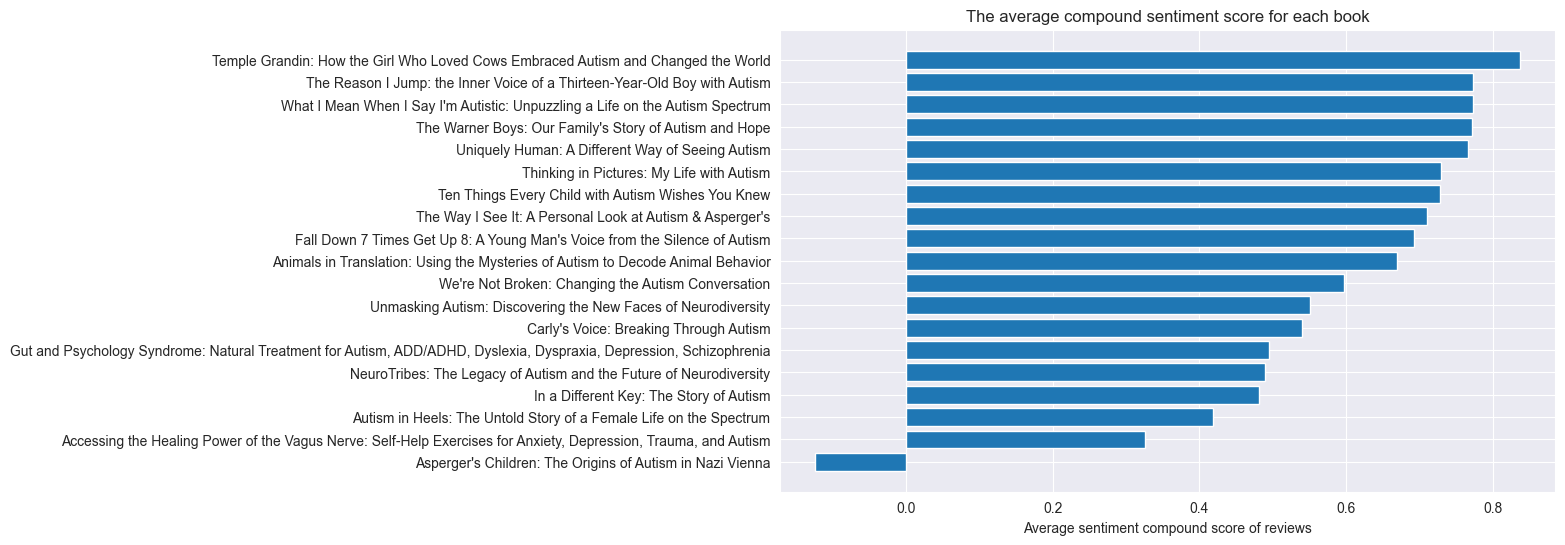

In [112]:
# Exploratory data analysis of the average sentiment compound score for each book
average_compound = merged_df2.groupby('book_title')['compound'].mean().reset_index(name='average_compound').sort_values(by='average_compound')
plt.figure(figsize=(10,6))
plt.barh(average_compound['book_title'], average_compound['average_compound'])
plt.xlabel('Average sentiment compound score of reviews')
plt.title('The average compound sentiment score for each book')

Text(0.5, 1.0, 'The total count for all the reviews for each book')

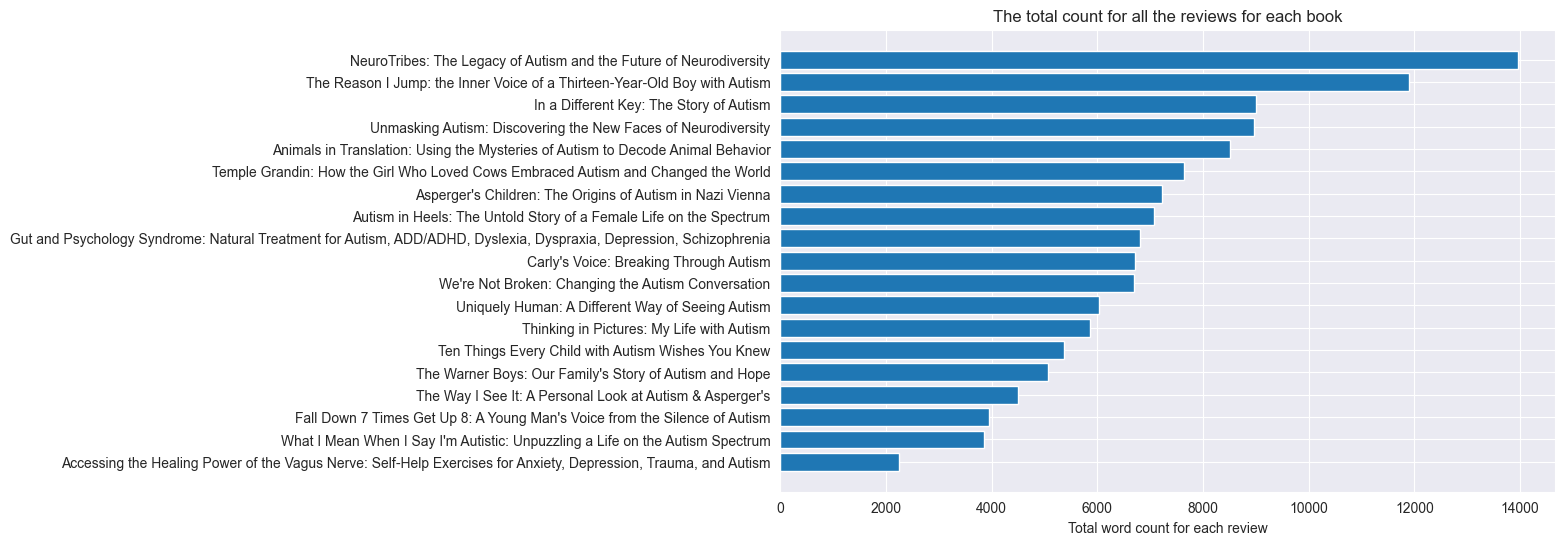

In [113]:
# Exploratory data analysis of the total word count for the reviews from each book
total_word_count = merged_df2.groupby('book_title')['word_count'].sum().reset_index(name='total_word_count').sort_values(by='total_word_count')
plt.figure(figsize=(10,6))
plt.barh(total_word_count['book_title'], total_word_count['total_word_count'])
plt.xlabel('Total word count for each review')
plt.title('The total count for all the reviews for each book')

Text(0.5, 1.0, 'The mean count for all the reviews for each book')

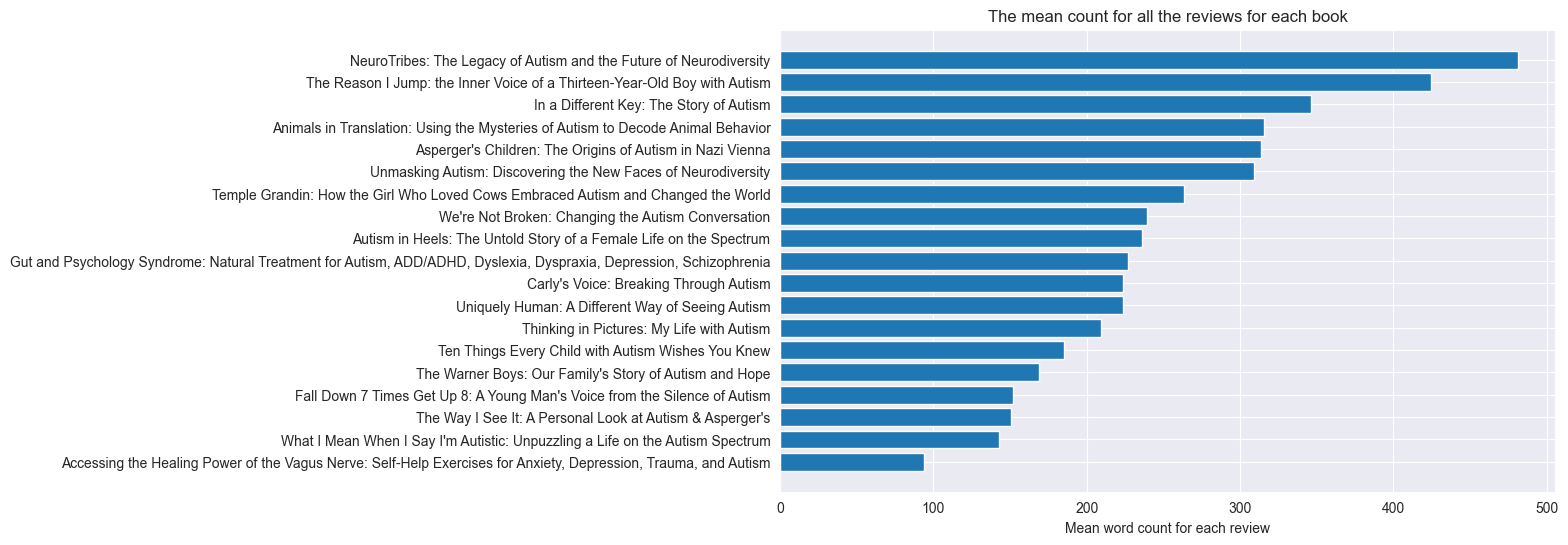

In [114]:
# Exploratory data analysis of the mean word count for the reviews from each book
mean_word_count = merged_df2.groupby('book_title')['word_count'].mean().reset_index(name='mean_word_count').sort_values(by='mean_word_count')
plt.figure(figsize=(10,6))
plt.barh(mean_word_count['book_title'], mean_word_count['mean_word_count'])
plt.xlabel('Mean word count for each review')
plt.title('The mean count for all the reviews for each book')

<Axes: title={'center': 'Word count distribution for each book review'}, ylabel='Frequency'>

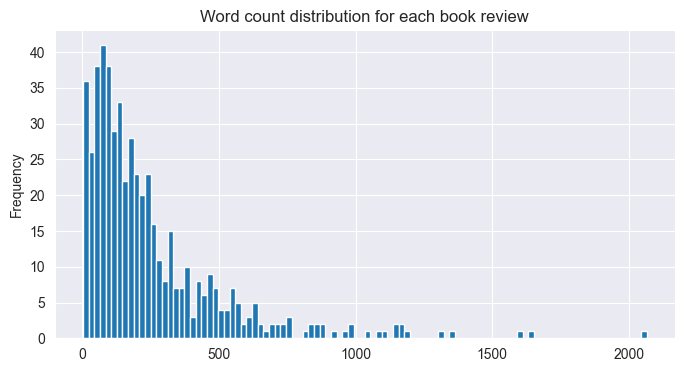

In [117]:
# Histogram showing the word distribution for each book review
merged_df2['word_count'].plot(kind = 'hist', bins = 100, figsize = (8,4), title = 'Word count distribution for each book review')

In [36]:
# Creating a binarised column for use in the algoritms created later on
merged_df2['sentiment_binarised'] = np.where(merged_df2['sentiment_label'] == 'positive', 1, 0)

In [37]:
# Create TF-IDF matrix on the cleaned corpus
tfidf_vectorizer = TfidfVectorizer(max_df=0.8, max_features=1500)
X = tfidf_vectorizer.fit_transform(merged_df2['Cleaned_review']).toarray()
y = merged_df2['sentiment_binarised']
vocabulary = tfidf_vectorizer.get_feature_names_out()

In [38]:
def freq_words(x, terms = 30): # show the most prevalent words in the corpus
  all_words = ' '.join([text for text in x]) 
  all_words = all_words.split() 
  fdist = nltk.FreqDist(all_words) 
  words_df = pd.DataFrame({'word':list(fdist.keys()), 'count':list(fdist.values())}) 
  
  # selecting top 20 most frequent words 
  d = words_df.nlargest(columns="count", n = terms) 
  
  # visualize words and frequencies
  plt.figure(figsize=(15,20)) 
  ax = sns.barplot(data=d, x= "count", y = "word") 
  ax.set(ylabel = 'Word') 
  plt.title('Frequency of words in the cleaned corpus, stopwords removed')
  # plt.tight_layout()
  plt.show()
  

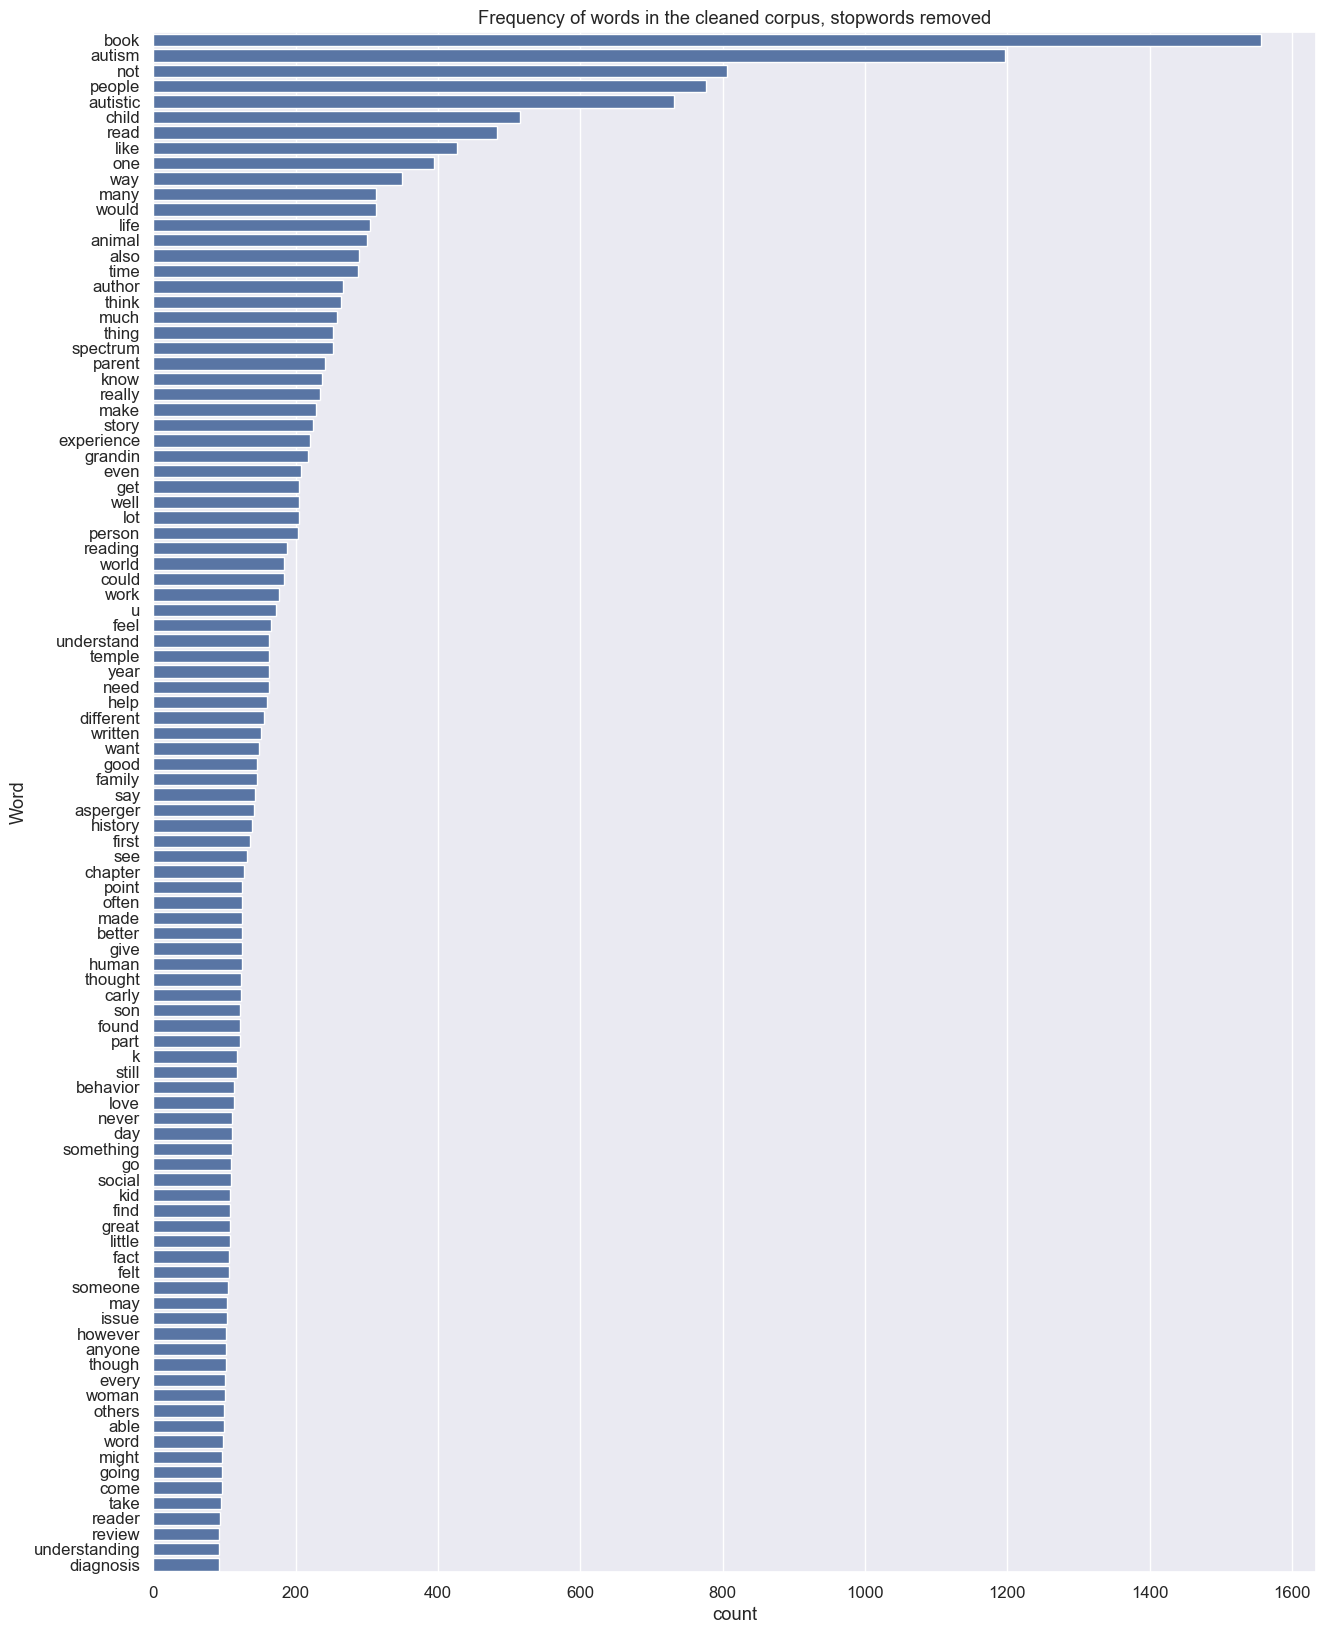

In [459]:
# print 100 most frequent words 
freq_words(merged_df2['Cleaned_review'], 100)

In [39]:
# Split the corupus and target up into train and test data using stratified sampling technique
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, stratify=y, random_state = 110)

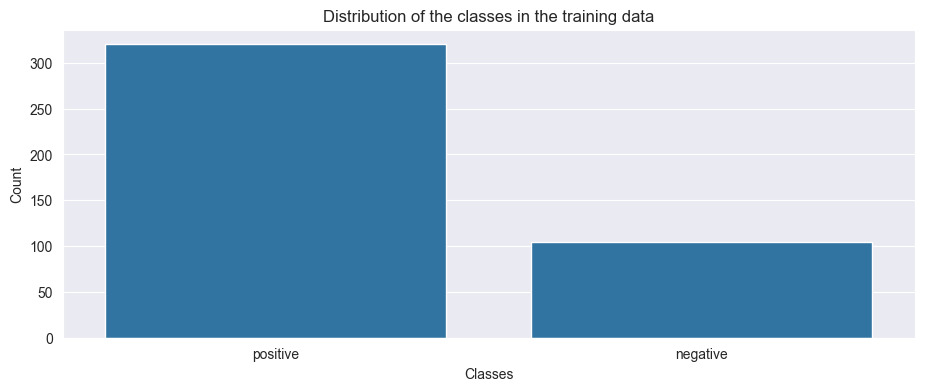

In [40]:
# Exploratory data analysis on the distribution classes in the training data
y_train_labeled = y_train.map({0: 'negative', 1: 'positive'})
plt.figure(figsize= (11,4))
sns.countplot(x = y_train_labeled)
plt.title('Distribution of the classes in the training data')
plt.xlabel('Classes')
plt.ylabel('Count')
plt.show()


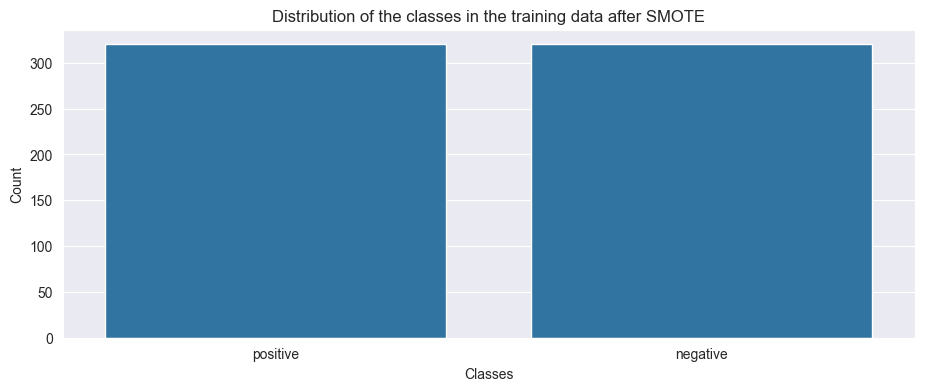

In [41]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state = 12, sampling_strategy = 1.0)
X_train_resampled, y_train_resampled = sm.fit_resample(X_train,y_train)

# Exploratory data analysis on the distribution classes in the training data after SMOTE sampling
y_train_resampled_relabeled = y_train_resampled.map({0: 'negative', 1: 'positive'})
plt.figure(figsize= (11,4))
sns.countplot(x = y_train_resampled_relabeled)
plt.title('Distribution of the classes in the training data after SMOTE')
plt.xlabel('Classes')
plt.ylabel('Count')
plt.show()

In [60]:
# Function to show the precision recall visualisation 
def plot_precision_recall(y_test,m_recall,m_precision,classifier_name):
    no_model = len(y_test[y_test==1]) / len(y_test)
    pyplot.plot([0, 1], [no_model, no_model], linestyle='--', label='No Model')
    pyplot.plot(m_recall, m_precision, marker='.', label=str(classifier_name))
    # axis labels
    pyplot.xlabel('Recall')
    pyplot.ylabel('Precision')
    # show the legend
    pyplot.legend()
    # show the plot
    pyplot.show()

In [61]:
# Function to show the AUC-ROC visualisation
def plot_roc_auc(y_test,probs, classifier):
    nm_probs = [0 for _ in range(len(y_test))]
    # calculate scores
    nm_auc = roc_auc_score(y_test, nm_probs)
    m_auc = roc_auc_score(y_test, probs)
    # summarize scores
    print('No Model: ROC AUC=%.3f' % (nm_auc))
    print('{}: ROC AUC={}'.format('classifier_name',m_auc))
    # calculate roc curves
    nm_fpr, nm_tpr, _ = roc_curve(y_test, nm_probs)
    fpr, tpr, _ = roc_curve(y_test, probs)
    # plot the roc curve for the model
    pyplot.plot(nm_fpr, nm_tpr, linestyle='--', label='No Model')
    pyplot.plot(fpr, tpr, marker='.', label=str(classifier))
    # axis labels
    pyplot.xlabel('False Positive Rate')
    pyplot.ylabel('True Positive Rate')
    # show the legend
    pyplot.legend()
    # show the plot
    pyplot.show()

In [81]:
# Function to train the classifiers using the split dataset
from time import time
def test_classifier(X_train_resampled, y_train_resampled, X_test, y_test, classifier):
    print("")
    print("******Classification of negative and positive reviews for books related to Autism ******")
    classifier_name = str(type(classifier).__name__)
    print("Testing " + classifier_name)
        
    now = time()
    list_of_labels = sorted(list(set(y_train_resampled)))
    model = classifier.fit(X_train_resampled, y_train_resampled)
    print("Learing time {0}s".format(time() - now))
    now = time()
    predictions = model.predict(X_test)
    probs = model.predict_proba(X_test)
    probs = probs[:, 1]
    print("Predicting time {0}s".format(time() - now))
    # calculate precision and recall for each threshold
    m_precision, m_recall, _ = precision_recall_curve(y_test, probs)
    precision = precision_score(y_test, predictions, average=None, pos_label=None, labels=list_of_labels)
    recall = recall_score(y_test, predictions, average=None, pos_label=None, labels=list_of_labels)
    accuracy = accuracy_score(y_test, predictions)
    f1 = f1_score(y_test, predictions, average=None, pos_label=None, labels=list_of_labels)
    cm = confusion_matrix(y_test, predictions)
    print("************ Results ************")
    print("         Negative        positive")
    print("F1       " + str(f1))
    print("Precision" + str(precision))
    print("Recall   " + str(recall))
    print("Accuracy " + str(accuracy))
    print('Confusion Matrix')
    print(cm)
    plot_roc_auc(y_test,probs, classifier_name)
    plot_precision_recall(y_test,m_recall,m_precision,classifier_name)
    
    
    return precision, recall, accuracy, f1


******Classification of negative and positive reviews for books related to Autism ******
Testing XGBClassifier
Learing time 0.793874979019165s
Predicting time 0.006981372833251953s
************ Results ************
         Negative        positive
F1       [0.5    0.8375]
Precision[0.5    0.8375]
Recall   [0.5    0.8375]
Accuracy 0.7547169811320755
Confusion Matrix
[[13 13]
 [13 67]]
No Model: ROC AUC=0.500
classifier_name: ROC AUC=0.7509615384615386


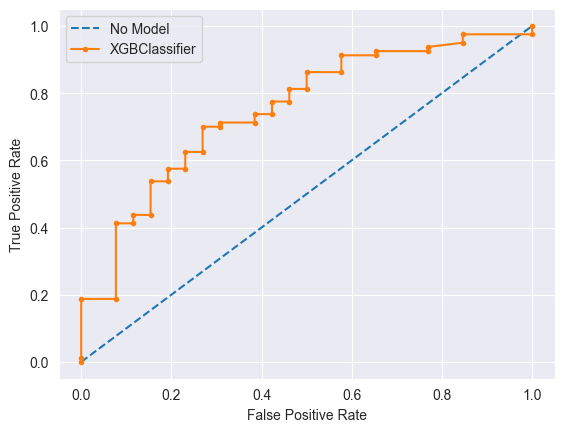

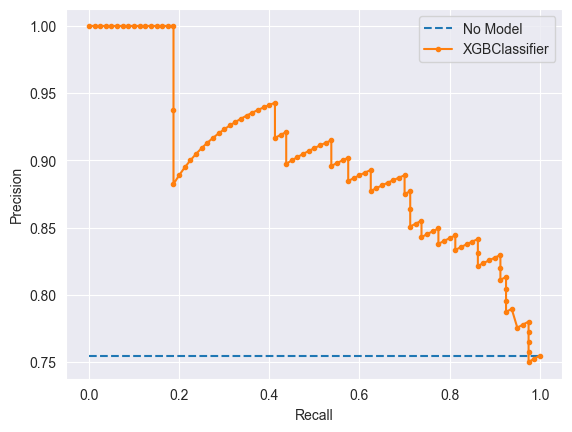


******Classification of negative and positive reviews for books related to Autism ******
Testing GaussianNB
Learing time 0.016955137252807617s
Predicting time 0.0069806575775146484s
************ Results ************
         Negative        positive
F1       [0.21621622 0.83428571]
Precision[0.36363636 0.76842105]
Recall   [0.15384615 0.9125    ]
Accuracy 0.7264150943396226
Confusion Matrix
[[ 4 22]
 [ 7 73]]
No Model: ROC AUC=0.500
classifier_name: ROC AUC=0.5341346153846154


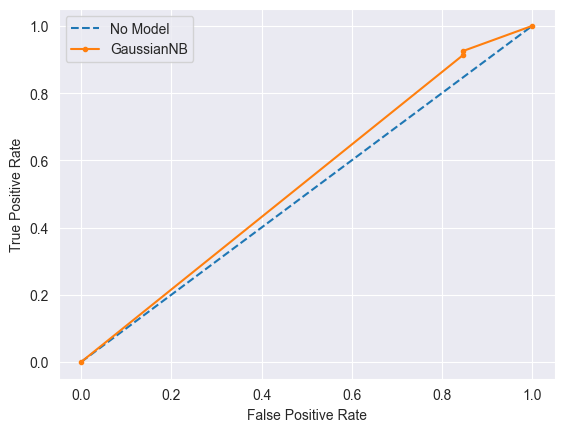

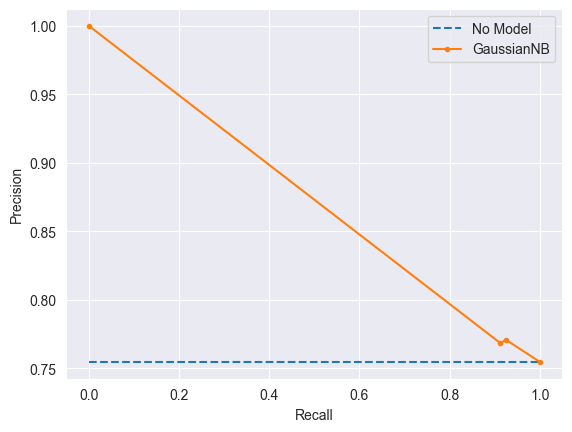


******Classification of negative and positive reviews for books related to Autism ******
Testing RandomForestClassifier
Learing time 0.27227258682250977s
Predicting time 0.009972333908081055s
************ Results ************
         Negative        positive
F1       [0.44897959 0.83435583]
Precision[0.47826087 0.81927711]
Recall   [0.42307692 0.85      ]
Accuracy 0.7452830188679245
Confusion Matrix
[[11 15]
 [12 68]]
No Model: ROC AUC=0.500
classifier_name: ROC AUC=0.7471153846153846


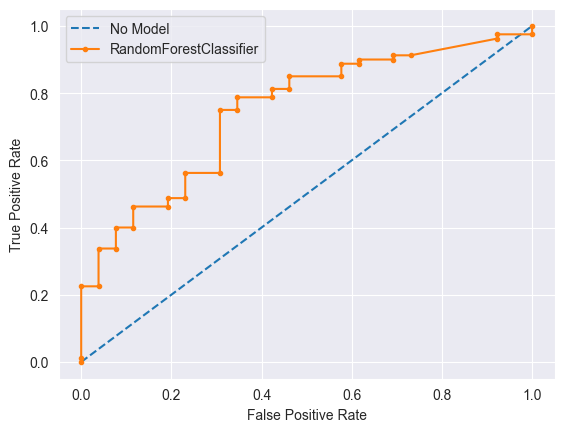

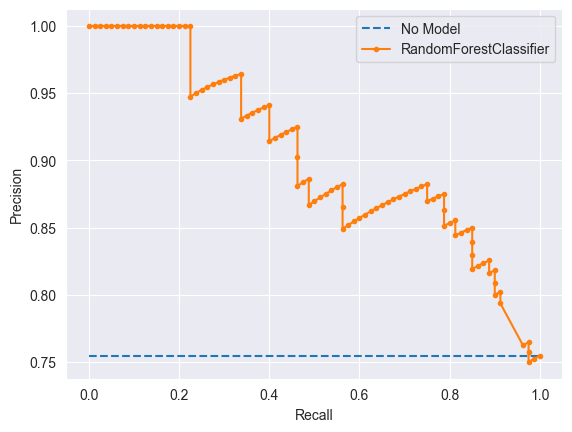


******Classification of negative and positive reviews for books related to Autism ******
Testing Pipeline
Learing time 1.1330022811889648s
Predicting time 0.10767865180969238s
************ Results ************
         Negative        positive
F1       [0.20689655 0.87431694]
Precision[1.         0.77669903]
Recall   [0.11538462 1.        ]
Accuracy 0.7830188679245284
Confusion Matrix
[[ 3 23]
 [ 0 80]]
No Model: ROC AUC=0.500
classifier_name: ROC AUC=0.49278846153846156


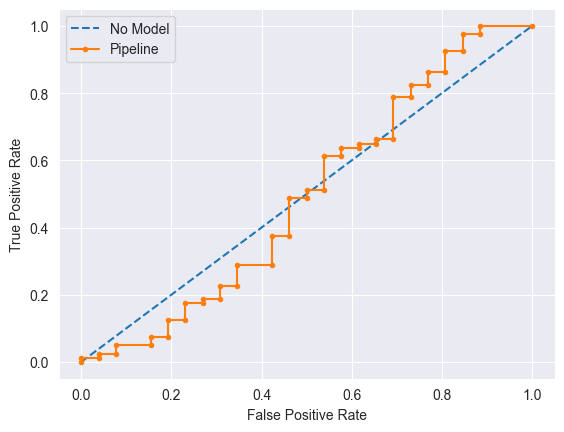

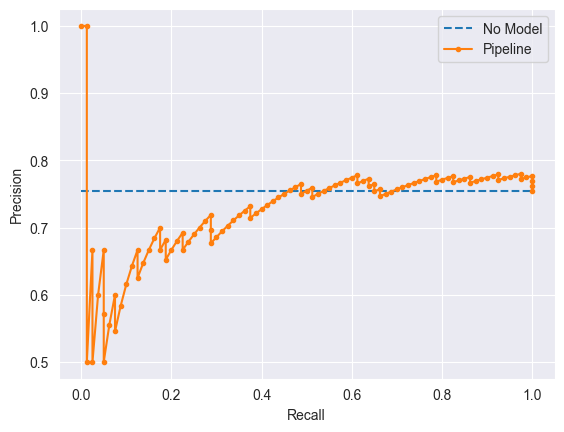


******Classification of negative and positive reviews for books related to Autism ******
Testing LogisticRegression
Learing time 0.018921375274658203s
Predicting time 0.0009970664978027344s
************ Results ************
         Negative        positive
F1       [0.48       0.83950617]
Precision[0.5        0.82926829]
Recall   [0.46153846 0.85      ]
Accuracy 0.7547169811320755
Confusion Matrix
[[12 14]
 [12 68]]
No Model: ROC AUC=0.500
classifier_name: ROC AUC=0.7485576923076923


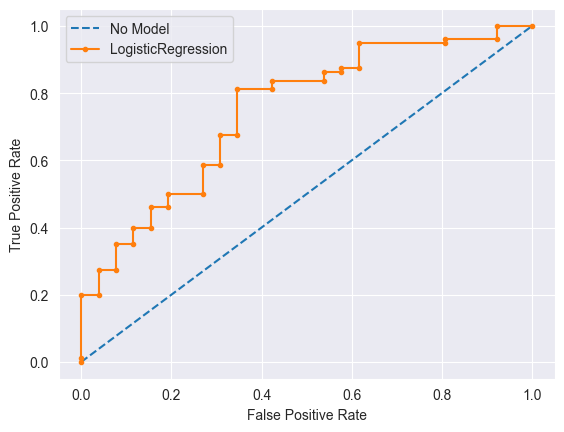

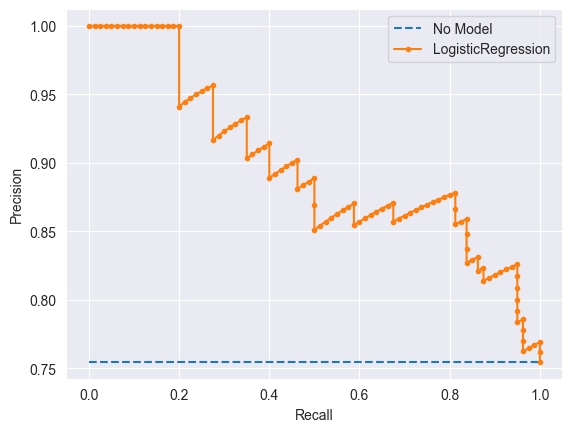

In [160]:
# Using the test_classifier function on different algoritms

precision, recall, accuracy, f1 = test_classifier(X_train_resampled, y_train_resampled, X_test, y_test, XGBoostClassifier(seed=0))

precision, recall, accuracy, f1 = test_classifier(X_train_resampled, y_train_resampled, X_test, y_test, GaussianNB())

precision, recall, accuracy, f1 = test_classifier(X_train_resampled, y_train_resampled, X_test, y_test, RandomForestClassifier(max_depth=2, random_state=0))

precision, recall, accuracy, f1 = test_classifier(X_train_resampled, y_train_resampled, X_test, y_test, make_pipeline(StandardScaler(), SVC(gamma='auto', probability=True)))

precision, recall, accuracy, f1 = test_classifier(X_train_resampled, y_train_resampled, X_test, y_test, LogisticRegression(random_state=0))

In [174]:
# Creating various different hyperparamter settings
search_space = {
    'max_depth': [3, 6, 9],
    'learning_rate': [0.001, 0.01, 0.1, 1],
    'n_estimators': [100, 200, 500],
    'gamma': [0.01, 0.1]
}


In [175]:
xgb_model = XGBClassifier()

In [176]:
# Performing gridsearchCV to tune the hyperparamters to find the optimal F1 score
gs = GridSearchCV(estimator=xgb_model,
                  param_grid=search_space,
                  scoring='f1',
                  cv=5,
                  verbose=4)

In [177]:
# Tuning the hyperparameters 
gs.fit(X_train_resampled, y_train_resampled)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
[CV 1/5] END gamma=0.01, learning_rate=0.001, max_depth=3, n_estimators=100;, score=0.659 total time=   0.5s
[CV 2/5] END gamma=0.01, learning_rate=0.001, max_depth=3, n_estimators=100;, score=0.713 total time=   0.3s
[CV 3/5] END gamma=0.01, learning_rate=0.001, max_depth=3, n_estimators=100;, score=0.724 total time=   0.4s
[CV 4/5] END gamma=0.01, learning_rate=0.001, max_depth=3, n_estimators=100;, score=0.544 total time=   0.5s
[CV 5/5] END gamma=0.01, learning_rate=0.001, max_depth=3, n_estimators=100;, score=0.591 total time=   0.3s
[CV 1/5] END gamma=0.01, learning_rate=0.001, max_depth=3, n_estimators=200;, score=0.654 total time=   1.6s
[CV 2/5] END gamma=0.01, learning_rate=0.001, max_depth=3, n_estimators=200;, score=0.713 total time=   0.8s
[CV 3/5] END gamma=0.01, learning_rate=0.001, max_depth=3, n_estimators=200;, score=0.739 total time=   0.6s
[CV 4/5] END gamma=0.01, learning_rate=0.001, max_depth=3, n_estim

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None,...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=None, ...),
             param_grid={'gamma': [0.01, 0.1],
                         'learning_rate': [0.001, 0.01, 0.1, 1],
                         'max_depth': [3, 6, 9],
                         'n_estimators': [100, 200, 500]},
             scoring='f1', verbose=4)

In [181]:
# Print the best settings 
print(gs.best_params_)

{'gamma': 0.01, 'learning_rate': 0.1, 'max_depth': 9, 'n_estimators': 100}


In [179]:
# Prints the highest F1 score
print(gs.best_score_)

0.8847017632830732


In [185]:
best_parameters = {
    'n_estimators': 100,
    'max_depth': 9,
    'learning_rate': 0.1,
    'gamma': 0.01
}

In [191]:
# Using the scale_pos_weight argument to help with the imbalanced classes
ratio = float(y_train.value_counts()[0]) / y_train.value_counts()[1]
model = XGBClassifier(scale_pos_weight=ratio)

sentiment_binarised
1    320
0    104
Name: count, dtype: int64

In [192]:
model.set_params(**best_parameters)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=0.01, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=9, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [193]:
model.fit(X_train_resampled, y_train_resampled)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=0.01, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=9, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)


******Classification of negative and positive reviews for books related to Autism ******
Testing XGBClassifier
Learing time 1.2157196998596191s
Predicting time 0.01196742057800293s
************ Results ************
         Negative        positive
F1       [0.51724138 0.81818182]
Precision[0.46875    0.85135135]
Recall   [0.57692308 0.7875    ]
Accuracy 0.7358490566037735
Confusion Matrix
[[15 11]
 [17 63]]
No Model: ROC AUC=0.500
classifier_name: ROC AUC=0.7557692307692307


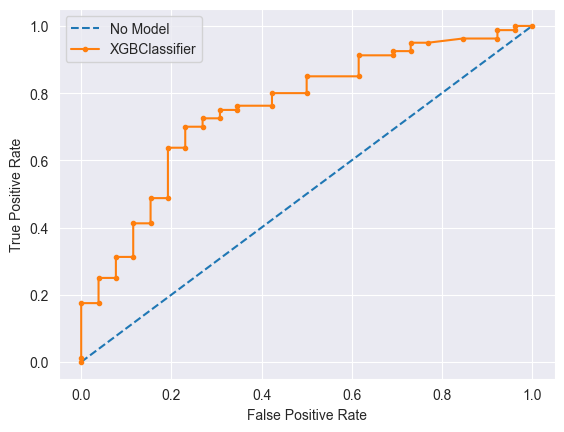

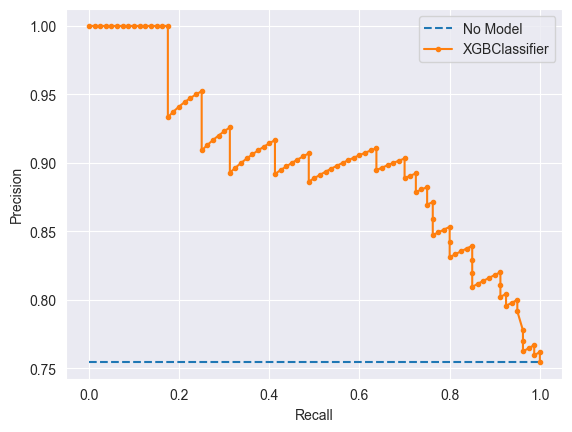

In [194]:
precision, recall, accuracy, f1 = test_classifier(X_train_resampled, y_train_resampled, X_test, y_test, model)